# 경복궁 SARIMAX 모델링

- 입력 데이터: `../data/preprocessed/eda_gbg_master.csv`
- 목적: baseline, KTCI, KTCI-a, KTCI-a2, rolling KTCI, decomposition model을 같은 SARIMAX 프레임에서 비교
- 포함: ADF, VIF, 코로나 더미 비교, 잔차 진단, 예측 시각화
- 공기질 변수는 `pm10 = ydst_pm10_open_hours`를 사용


In [30]:
# ============================================================
# 0. 라이브러리 및 설정
# ============================================================
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, coint
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "modeling" else Path.cwd()
MASTER_PATH = PROJECT_ROOT / "data" / "preprocessed" / "eda_gbg_master.csv"

if not MASTER_PATH.exists():
    raise FileNotFoundError(f"필수 입력 파일이 없습니다: {MASTER_PATH}")

TARGET_COL = "visitors"
DECOMP_COLS = ["Cd", "Ca", "P", "W", "S"]
RAW_DECOMP_COLS = DECOMP_COLS.copy()
REDUCED_DECOMP_COLS = ["Cd_c", "Ca_c", "W_c", "S_c"]
SCALAR_MAIN_VARS = [
    "tavg",
    "ktci",
    "ktci_a",
    "ktci_a2",
    "ktci_a_roll3",
    "ktci_a_roll7",
]
COVID_COMPARE_COLS = ["covid_v1", "covid_v2", "covid_v3"]
DEFAULT_COVID_COL = "covid_v3"
EVENT_CONTROL_COLS = [
    "event_day",
    "event_count",
    "night_event_count",
]
DEFAULT_INCLUDE_EVENTS = True
RAW_CONTROL_COLS = [
    "rain",
    "pm10",
    DEFAULT_COVID_COL,
    "closed",
    "others_closed",
    "is_weekend",
    "d_holiday",
]
DERIVED_HOLIDAY_COLS = [
    "offdays_left",
    "long_break_3p",
    "pre_holiday",
]
BASE_CONTROL_COLS = [
    *RAW_CONTROL_COLS,
    *DERIVED_HOLIDAY_COLS,
]
COMMON_INTERACTION_COLS = [
    "rain_c_x_weekend",
    "rain_c_x_offdays_left",
]
MAIN_VARIABLES = {
    "Baseline (Temperature)": "tavg",
    "KTCI Model": "ktci",
    "KTCI-a Model": "ktci_a",
    "KTCI-a2 Model": "ktci_a2",
    "KTCI-a_roll3 Model": "ktci_a_roll3",
    "KTCI-a_roll7 Model": "ktci_a_roll7",
    "Decomposition Reduced Model": REDUCED_DECOMP_COLS,
}

SARIMAX_ORDER = (2, 0, 1)
SEASONAL_ORDER = (1, 0, 1, 7)
MAXITER = 200
TEST_SIZE = 365

TARGET_COMPARISON_MODELS = [
    "Baseline (Temperature)",
    "KTCI-a_roll7 Model",
    "Decomposition Reduced Model",
]


def mean_absolute_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def mean_squared_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot


In [31]:
# ============================================================
# 1. 데이터 로드
# ============================================================
master = pd.read_csv(MASTER_PATH, encoding="utf-8-sig")
master["date"] = pd.to_datetime(master["date"])

print("master shape:", master.shape)
display(master.head())


master shape: (6209, 94)


,date,year,month,day,dow,dow_name,is_weekend,is_regular_closed_tuesday,closed,others_closed,...,Ca,P,W,S,pm10,wind_speed,humidity,solar_rad,event_day,covid_stage
0,2009-01-01,2009,1,1,3,목,0,0,0,0,...,1.5,5.0,4.0,4.40,43.000,2.3,45.8,9.49,0,non_covid_period
1,2009-01-02,2009,1,2,4,금,0,0,0,0,...,1.5,5.0,4.5,4.40,52.250,1.6,51.5,8.87,0,non_covid_period
2,2009-01-03,2009,1,3,5,토,1,0,0,0,...,2.0,5.0,4.0,4.40,56.750,1.8,48.3,8.73,0,non_covid_period
3,2009-01-04,2009,1,4,6,일,1,0,0,0,...,2.0,5.0,4.0,4.20,42.875,1.9,44.3,9.02,0,non_covid_period
4,2009-01-05,2009,1,5,0,월,0,0,0,2,...,2.0,5.0,4.0,2.45,62.750,2.2,53.1,6.32,0,non_covid_period


In [32]:
# ============================================================
# 2. 날짜 정리
# ============================================================
df = master.copy()
df = df.set_index("date").sort_index().asfreq("D")

print("df shape:", df.shape)
print("period:", df.index.min(), "~", df.index.max())
for col in ["ktci", "ktci_a", "ktci_a2", "ktci_a_roll3", "ktci_a_roll7", "pm10", "closed", "others_closed", "d_holiday"]:
    print(f"{col} missing:", df[col].isna().sum())

display(df[["visitors", "tavg", "ktci", "ktci_a", "ktci_a2", "ktci_a_roll3", "ktci_a_roll7", *DECOMP_COLS, "pm10", "closed", "others_closed", "d_holiday"]].head())


df shape: (6209, 93)
period: 2009-01-01 00:00:00 ~ 2025-12-31 00:00:00
ktci missing: 0
ktci_a missing: 0
ktci_a2 missing: 0
ktci_a_roll3 missing: 0
ktci_a_roll7 missing: 0
pm10 missing: 283
closed missing: 0
others_closed missing: 0
d_holiday missing: 0


,visitors,tavg,ktci,ktci_a,ktci_a2,ktci_a_roll3,ktci_a_roll7,Cd,Ca,P,W,S,pm10,closed,others_closed,d_holiday
date,,,,,,,,,,,,,,,,
2009-01-01,9966,-5.8,65.76,65.76,65.76,65.76,65.76,2.0,1.5,5.0,4.0,4.40,43.000,0,0,1
2009-01-02,7871,-2.8,67.22,67.22,67.22,66.49,66.49,2.0,1.5,5.0,4.5,4.40,52.250,0,0,0
2009-01-03,10553,-1.0,70.42,70.42,70.42,67.80,67.80,2.5,2.0,5.0,4.0,4.40,56.750,0,0,0
2009-01-04,7928,0.4,70.09,70.09,70.09,69.24,68.37,2.5,2.0,5.0,4.0,4.20,42.875,0,0,0
2009-01-05,5056,-1.6,64.99,64.99,64.99,68.50,67.70,2.0,2.0,5.0,4.0,2.45,62.750,0,2,0


In [33]:
# ============================================================
# 3. 모델링 데이터 정리 + 연휴/상호작용 변수 생성
# ============================================================
required_cols = [
    TARGET_COL,
    *SCALAR_MAIN_VARS,
    *DECOMP_COLS,
    "season_month",
    "season_temp",
    "rain",
    "pm10",
    "closed",
    "others_closed",
    "is_weekend",
    "d_holiday",
    *COVID_COMPARE_COLS,
    *EVENT_CONTROL_COLS,
]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"필요한 컬럼이 없습니다: {missing_cols}")

model_df = df[[
    TARGET_COL,
    *SCALAR_MAIN_VARS,
    *DECOMP_COLS,
    "season_month",
    "season_temp",
    "rain",
    "pm10",
    "closed",
    "others_closed",
    "is_weekend",
    "d_holiday",
    *COVID_COMPARE_COLS,
    *EVENT_CONTROL_COLS,
]].copy()

numeric_cols = [
    TARGET_COL,
    *SCALAR_MAIN_VARS,
    *DECOMP_COLS,
    "rain",
    "pm10",
    "closed",
    "others_closed",
    "is_weekend",
    "d_holiday",
    *COVID_COMPARE_COLS,
    *EVENT_CONTROL_COLS,
]
for col in numeric_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# 기상/쾌적도 계열은 시간축 기준 보간
interpolate_cols = [*SCALAR_MAIN_VARS[1:], *DECOMP_COLS, "pm10"]
for col in interpolate_cols:
    model_df[col] = model_df[col].interpolate(method="time").ffill().bfill()

# 휴일/운영 더미는 결측이 있으면 0으로 처리
fill_zero_cols = ["rain", "closed", "others_closed", "is_weekend", "d_holiday", *COVID_COMPARE_COLS, *EVENT_CONTROL_COLS]
for col in fill_zero_cols:
    model_df[col] = model_df[col].fillna(0)

model_df = model_df.sort_index()

remaining_missing = model_df[numeric_cols].isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if not remaining_missing.empty:
    raise ValueError(f"전처리 후에도 결측이 남아 있습니다: {remaining_missing.to_dict()}")

model_df["offday"] = ((model_df["is_weekend"] == 1) | (model_df["d_holiday"] == 1)).astype(int)
model_df["next_day_off"] = model_df["offday"].shift(-1, fill_value=0).astype(int)
model_df["pre_holiday"] = ((model_df["offday"] == 0) & (model_df["next_day_off"] == 1)).astype(int)

offday_group = model_df["offday"].ne(model_df["offday"].shift(fill_value=0)).cumsum()
offday_block_total = model_df.groupby(offday_group)["offday"].transform("sum")
offday_position = model_df.groupby(offday_group).cumcount() + 1
model_df["offdays_left"] = np.where(
    model_df["offday"] == 1,
    offday_block_total - offday_position + 1,
    0,
).astype(int)
model_df["long_break_3p"] = ((model_df["offday"] == 1) & (offday_block_total >= 3)).astype(int)

# 상호작용 공선성 완화를 위해 연속형 변수는 평균중심화 후 interaction 생성
for col in ["rain", *SCALAR_MAIN_VARS, *DECOMP_COLS]:
    model_df[f"{col}_c"] = model_df[col] - model_df[col].mean()

model_df["rain_c_x_weekend"] = model_df["rain_c"] * model_df["is_weekend"]
model_df["rain_c_x_offdays_left"] = model_df["rain_c"] * model_df["offdays_left"]

for main_var in SCALAR_MAIN_VARS:
    model_df[f"{main_var}_c_x_weekend"] = model_df[f"{main_var}_c"] * model_df["is_weekend"]
    model_df[f"{main_var}_c_x_offdays_left"] = model_df[f"{main_var}_c"] * model_df["offdays_left"]

for component in DECOMP_COLS:
    model_df[f"{component}_c_x_weekend"] = model_df[f"{component}_c"] * model_df["is_weekend"]
    model_df[f"{component}_c_x_offdays_left"] = model_df[f"{component}_c"] * model_df["offdays_left"]

model_df["Cd_c"] = model_df["Cd_c"]
model_df["Ca_c"] = model_df["Ca_c"]
model_df["W_c"] = model_df["W_c"]
model_df["S_c"] = model_df["S_c"]

if len(model_df) <= TEST_SIZE:
    raise ValueError(f"TEST_SIZE={TEST_SIZE}가 데이터 길이보다 큽니다.")

train_df = model_df.iloc[:-TEST_SIZE].copy()
test_df = model_df.iloc[-TEST_SIZE:].copy()

print("model_df shape:", model_df.shape)
print("train period:", train_df.index.min(), "~", train_df.index.max(), f"({len(train_df)} rows)")
print("test period:", test_df.index.min(), "~", test_df.index.max(), f"({len(test_df)} rows)")
print("days with next day off:", int(model_df["next_day_off"].sum()))
print("days in 3+ day breaks:", int(model_df["long_break_3p"].sum()))
print("days before holiday blocks:", int(model_df["pre_holiday"].sum()))
print("pm10 interpolated days:", int(df["pm10"].isna().sum()))

display(model_df[[TARGET_COL, *SCALAR_MAIN_VARS, *DECOMP_COLS, *REDUCED_DECOMP_COLS, "next_day_off", "offdays_left", "long_break_3p", "pre_holiday"]].head(10))


model_df shape: (6209, 67)
train period: 2009-01-01 00:00:00 ~ 2024-12-31 00:00:00 (5844 rows)
test period: 2025-01-01 00:00:00 ~ 2025-12-31 00:00:00 (365 rows)
days with next day off: 1985
days in 3+ day breaks: 312
days before holiday blocks: 956
pm10 interpolated days: 283


,visitors,tavg,ktci,ktci_a,ktci_a2,ktci_a_roll3,ktci_a_roll7,Cd,Ca,P,W,S,Cd_c,Ca_c,W_c,S_c,next_day_off,offdays_left,long_break_3p,pre_holiday
date,,,,,,,,,,,,,,,,,,,,
2009-01-01,9966,-5.8,65.76,65.76,65.76,65.76,65.76,2.0,1.5,5.0,4.0,4.40,-1.475036,-1.781688,0.150749,1.307135,0,1,0,0
2009-01-02,7871,-2.8,67.22,67.22,67.22,66.49,66.49,2.0,1.5,5.0,4.5,4.40,-1.475036,-1.781688,0.650749,1.307135,1,0,0,1
2009-01-03,10553,-1.0,70.42,70.42,70.42,67.80,67.80,2.5,2.0,5.0,4.0,4.40,-0.975036,-1.281688,0.150749,1.307135,1,2,0,0
2009-01-04,7928,0.4,70.09,70.09,70.09,69.24,68.37,2.5,2.0,5.0,4.0,4.20,-0.975036,-1.281688,0.150749,1.107135,0,1,0,0
2009-01-05,5056,-1.6,64.99,64.99,64.99,68.50,67.70,2.0,2.0,5.0,4.0,2.45,-1.475036,-1.281688,0.150749,-0.642865,0,0,0,0
2009-01-06,0,-2.0,65.07,65.07,65.07,66.72,67.26,2.0,2.0,5.0,4.0,2.50,-1.475036,-1.281688,0.150749,-0.592865,0,0,0,0
2009-01-07,4571,-0.5,70.26,70.26,70.26,66.77,67.69,2.5,2.0,5.0,4.0,4.30,-0.975036,-1.281688,0.150749,1.207135,0,0,0,0
2009-01-08,3567,-0.9,68.31,68.31,68.31,67.88,68.05,2.5,2.0,5.0,4.0,3.10,-0.975036,-1.281688,0.150749,0.007135,0,0,0,0
2009-01-09,3456,-3.5,62.76,62.76,62.76,67.11,67.41,2.0,1.5,5.0,3.5,3.45,-1.475036,-1.781688,-0.349251,0.357135,1,0,0,1


In [34]:
# ============================================================
# 4. 기초 확인: 방문객 수와 후보 변수 관계
# ============================================================
corr_cols = list(dict.fromkeys([
    TARGET_COL,
    *SCALAR_MAIN_VARS,
    *DECOMP_COLS,
    "offdays_left",
    "long_break_3p",
    "pre_holiday",
    "rain_c_x_weekend",
    "rain_c_x_offdays_left",
    "tavg_c_x_weekend",
    "tavg_c_x_offdays_left",
    "ktci_c_x_weekend",
    "ktci_c_x_offdays_left",
    "ktci_a_c_x_weekend",
    "ktci_a_c_x_offdays_left",
    *BASE_CONTROL_COLS,
]))
corr_df = model_df[corr_cols].corr(numeric_only=True)[[TARGET_COL]].sort_values(TARGET_COL, ascending=False)
display(corr_df)


,visitors
visitors,1.000000
offdays_left,0.411230
long_break_3p,0.367376
d_holiday,0.338054
is_weekend,0.248116
ktci_a2,0.231661
ktci_a,0.231163
ktci,0.229546
ktci_a_c_x_offdays_left,0.223100
ktci_c_x_offdays_left,0.221240


,series,ADF Statistic,p-value,usedlag,nobs,1%,5%,10%
0,visitors,-6.3327,0.0,34,6174,-3.4314,-2.862,-2.567
1,tavg,-6.0868,0.0,34,6174,-3.4314,-2.862,-2.567
2,ktci,-7.0461,0.0,17,6191,-3.4314,-2.862,-2.567
3,ktci_a,-7.0653,0.0,17,6191,-3.4314,-2.862,-2.567
4,ktci_a2,-7.0374,0.0,17,6191,-3.4314,-2.862,-2.567
5,ktci_a_roll3,-7.1662,0.0,34,6174,-3.4314,-2.862,-2.567
6,ktci_a_roll7,-7.6628,0.0,33,6175,-3.4314,-2.862,-2.567


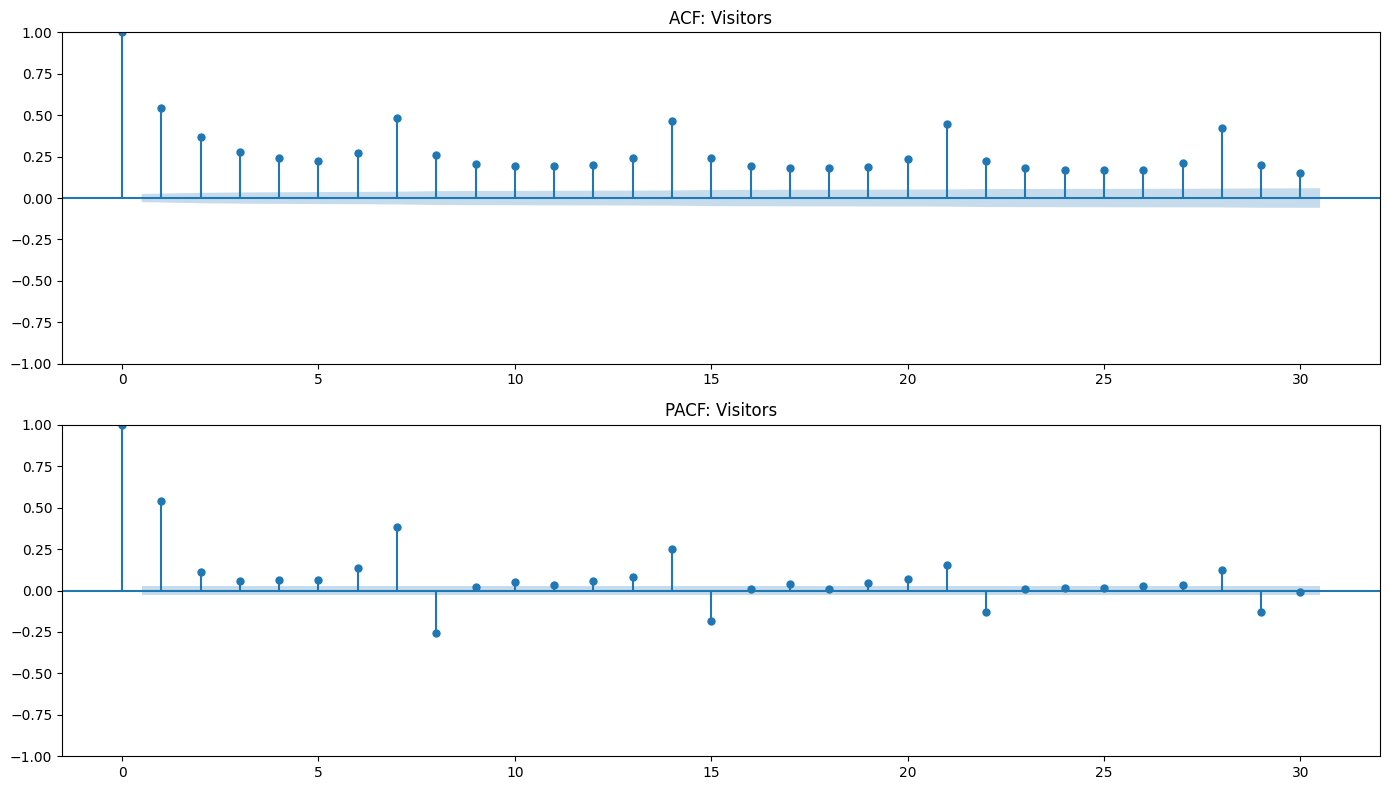

In [35]:
# ============================================================
# 5. 정상성 진단: ADF 검정 + 기본 ACF/PACF
# ============================================================
def run_adf_test(series, name):
    test_series = series.dropna()
    stat, p_value, usedlag, nobs, critical_values, _ = adfuller(test_series, autolag="AIC")
    return {
        "series": name,
        "ADF Statistic": stat,
        "p-value": p_value,
        "usedlag": usedlag,
        "nobs": nobs,
        "1%": critical_values["1%"],
        "5%": critical_values["5%"],
        "10%": critical_values["10%"],
    }

adf_targets = {name: model_df[name] for name in [TARGET_COL, *SCALAR_MAIN_VARS]}
adf_df = pd.DataFrame([run_adf_test(series, name) for name, series in adf_targets.items()])
display(adf_df.round(4))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(model_df[TARGET_COL], ax=axes[0], lags=30, title="ACF: Visitors")
plot_pacf(model_df[TARGET_COL], ax=axes[1], lags=30, title="PACF: Visitors", method="ywm")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 5-1. Granger causality tests: raw levels + calendar-adjusted residuals
# ============================================================
GRANGER_MAXLAG = 14
GRANGER_FEATURES = [
    "tavg",
    "rain",
    "pm10",
    "event_count",
    "night_event_count",
    "ktci",
    "ktci_a",
    "ktci_a2",
    "ktci_a_roll3",
    "ktci_a_roll7",
    "Cd",
    "Ca",
    "P",
    "W",
    "S",
]
GRANGER_FEATURES = [col for col in GRANGER_FEATURES if col in model_df.columns]


def _granger_pair(frame, caused, causing, maxlag=GRANGER_MAXLAG):
    pair = frame[[caused, causing]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(pair) <= maxlag + 5 or pair[caused].nunique() <= 1 or pair[causing].nunique() <= 1:
        return None

    results = grangercausalitytests(pair, maxlag=maxlag, verbose=False)
    lag_rows = []
    for lag, values in results.items():
        f_stat, p_value, df_denom, df_num = values[0]["ssr_ftest"]
        lag_rows.append({
            "lag": lag,
            "f_stat": f_stat,
            "p_value": p_value,
            "df_denom": df_denom,
            "df_num": df_num,
        })

    lag_df = pd.DataFrame(lag_rows)
    best = lag_df.loc[lag_df["p_value"].idxmin()]
    return {
        "caused": caused,
        "causing": causing,
        "best_lag": int(best["lag"]),
        "min_p_value": float(best["p_value"]),
        "best_f_stat": float(best["f_stat"]),
        "p_lag_1": float(lag_df.loc[lag_df["lag"] == 1, "p_value"].iloc[0]),
        "p_lag_7": float(lag_df.loc[lag_df["lag"] == 7, "p_value"].iloc[0]),
        "p_lag_14": float(lag_df.loc[lag_df["lag"] == 14, "p_value"].iloc[0]),
        "n_obs": int(len(pair)),
    }


def _build_calendar_adjustment_controls(frame):
    control_cols = [
        "closed",
        "others_closed",
        "is_weekend",
        "d_holiday",
        DEFAULT_COVID_COL,
        "offdays_left",
        "long_break_3p",
        "pre_holiday",
    ]
    controls = frame[[col for col in control_cols if col in frame.columns]].astype(float).copy()

    dow_dummies = pd.get_dummies(frame.index.dayofweek, prefix="dow", drop_first=True, dtype=float)
    dow_dummies.index = frame.index
    month_dummies = pd.get_dummies(frame.index.month, prefix="month", drop_first=True, dtype=float)
    month_dummies.index = frame.index
    return pd.concat([controls, dow_dummies, month_dummies], axis=1)


def _residualize_on_controls(series, controls):
    y = pd.to_numeric(series, errors="coerce").astype(float)
    X = controls.astype(float).copy()
    X.insert(0, "const", 1.0)
    valid = y.notna() & X.notna().all(axis=1)

    residual = pd.Series(np.nan, index=y.index, name=f"{series.name}_resid")
    if valid.sum() <= X.shape[1] + 2:
        return residual

    beta = np.linalg.lstsq(X.loc[valid].to_numpy(), y.loc[valid].to_numpy(), rcond=None)[0]
    residual.loc[valid] = y.loc[valid] - X.loc[valid].to_numpy() @ beta
    return residual


def _run_granger_suite(frame, features, target_col=TARGET_COL, series_type="raw_level"):
    rows = []
    for feature in features:
        forward = _granger_pair(frame, target_col, feature)
        if forward is not None:
            rows.append({
                "series_type": series_type,
                "feature": feature,
                "direction_kind": "feature_to_visitors",
                "direction": f"{feature} -> {target_col}",
                **forward,
            })

        reverse = _granger_pair(frame, feature, target_col)
        if reverse is not None:
            rows.append({
                "series_type": series_type,
                "feature": feature,
                "direction_kind": "visitors_to_feature",
                "direction": f"{target_col} -> {feature}",
                **reverse,
            })
    return pd.DataFrame(rows)


raw_granger_df = _run_granger_suite(model_df, GRANGER_FEATURES, series_type="raw_level")

calendar_controls = _build_calendar_adjustment_controls(model_df)
adjusted_frame = pd.DataFrame(index=model_df.index)
adjusted_frame[f"{TARGET_COL}_resid"] = _residualize_on_controls(model_df[TARGET_COL], calendar_controls)
for feature in GRANGER_FEATURES:
    adjusted_frame[f"{feature}_resid"] = _residualize_on_controls(model_df[feature], calendar_controls)

adjusted_granger_rows = []
for feature in GRANGER_FEATURES:
    y_resid = f"{TARGET_COL}_resid"
    x_resid = f"{feature}_resid"

    forward = _granger_pair(adjusted_frame, y_resid, x_resid)
    if forward is not None:
        adjusted_granger_rows.append({
            "series_type": "calendar_adjusted_resid",
            "feature": feature,
            "direction_kind": "feature_to_visitors",
            "direction": f"{feature} -> {TARGET_COL}",
            **forward,
        })

    reverse = _granger_pair(adjusted_frame, x_resid, y_resid)
    if reverse is not None:
        adjusted_granger_rows.append({
            "series_type": "calendar_adjusted_resid",
            "feature": feature,
            "direction_kind": "visitors_to_feature",
            "direction": f"{TARGET_COL} -> {feature}",
            **reverse,
        })

adjusted_granger_df = pd.DataFrame(adjusted_granger_rows)
granger_summary_df = pd.concat([raw_granger_df, adjusted_granger_df], ignore_index=True)

for (series_type, direction_kind), idx in granger_summary_df.groupby(["series_type", "direction_kind"]).groups.items():
    valid_idx = granger_summary_df.loc[idx, "min_p_value"].dropna().index
    if len(valid_idx) == 0:
        continue
    _, q_values, _, _ = multipletests(granger_summary_df.loc[valid_idx, "min_p_value"], alpha=0.05, method="fdr_bh")
    granger_summary_df.loc[valid_idx, "fdr_q_value"] = q_values

granger_summary_df = granger_summary_df.sort_values(
    ["series_type", "direction_kind", "fdr_q_value", "min_p_value"]
).reset_index(drop=True)

MODELING_OUTPUT_DIR = PROJECT_ROOT / "data" / "modeling"
MODELING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
granger_summary_df.to_csv(MODELING_OUTPUT_DIR / "granger_causality_summary.csv", index=False, encoding="utf-8-sig")

summary_cols = [
    "series_type",
    "feature",
    "direction",
    "best_lag",
    "min_p_value",
    "fdr_q_value",
    "p_lag_1",
    "p_lag_7",
    "p_lag_14",
    "n_obs",
]

print("Feature -> visitors, raw levels")
display(
    granger_summary_df[
        (granger_summary_df["series_type"] == "raw_level")
        & (granger_summary_df["direction_kind"] == "feature_to_visitors")
    ][summary_cols].head(15).round(6)
)

print("Feature -> visitors, calendar-adjusted residuals")
display(
    granger_summary_df[
        (granger_summary_df["series_type"] == "calendar_adjusted_resid")
        & (granger_summary_df["direction_kind"] == "feature_to_visitors")
    ][summary_cols].head(15).round(6)
)

print("Visitors -> feature, calendar-adjusted residuals")
display(
    granger_summary_df[
        (granger_summary_df["series_type"] == "calendar_adjusted_resid")
        & (granger_summary_df["direction_kind"] == "visitors_to_feature")
    ][summary_cols].head(15).round(6)
)

print("Saved:", MODELING_OUTPUT_DIR / "granger_causality_summary.csv")


In [ ]:
# ============================================================
# 5-2. Engle-Granger cointegration tests
# ============================================================
COINTEGRATION_FEATURES = GRANGER_FEATURES.copy()


def _adf_level_p_value(series):
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.nunique() <= 1:
        return np.nan
    return adfuller(values, autolag="AIC")[1]


def _run_cointegration_test(frame, feature, target_col=TARGET_COL):
    pair = frame[[target_col, feature]].replace([np.inf, -np.inf], np.nan).dropna()
    y_adf_p = _adf_level_p_value(pair[target_col])
    x_adf_p = _adf_level_p_value(pair[feature])

    try:
        coint_t, coint_p, critical_values = coint(pair[target_col], pair[feature], trend="c", autolag="aic")
        crit_1pct, crit_5pct, crit_10pct = critical_values
    except Exception:
        coint_t, coint_p, crit_1pct, crit_5pct, crit_10pct = [np.nan] * 5

    both_i1_candidate = bool((y_adf_p >= 0.05) and (x_adf_p >= 0.05))
    return {
        "feature": feature,
        "n_obs": int(len(pair)),
        "visitors_adf_p": y_adf_p,
        "feature_adf_p": x_adf_p,
        "both_nonstationary_i1_candidate": both_i1_candidate,
        "coint_t_stat": coint_t,
        "coint_p_value": coint_p,
        "crit_1pct": crit_1pct,
        "crit_5pct": crit_5pct,
        "crit_10pct": crit_10pct,
    }


cointegration_df = pd.DataFrame([
    _run_cointegration_test(model_df, feature)
    for feature in COINTEGRATION_FEATURES
]).sort_values("coint_p_value").reset_index(drop=True)

cointegration_df["eg_reject_5pct"] = cointegration_df["coint_p_value"] < 0.05
cointegration_df["interpretation"] = np.where(
    ~cointegration_df["both_nonstationary_i1_candidate"],
    "not_interpreted_i0_precondition_failed",
    np.where(cointegration_df["eg_reject_5pct"], "cointegrated_5pct", "not_cointegrated_5pct"),
)

MODELING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
cointegration_df.to_csv(MODELING_OUTPUT_DIR / "cointegration_summary.csv", index=False, encoding="utf-8-sig")

print(
    "Cointegration is interpreted only when both level series are non-stationary. "
    "Here, low ADF p-values indicate level-stationary I(0) series, so Engle-Granger "
    "rejections are reported but not treated as long-run equilibrium evidence."
)

display(
    cointegration_df[[
        "feature",
        "visitors_adf_p",
        "feature_adf_p",
        "both_nonstationary_i1_candidate",
        "coint_t_stat",
        "coint_p_value",
        "eg_reject_5pct",
        "interpretation",
    ]].round(6)
)

print("Saved:", MODELING_OUTPUT_DIR / "cointegration_summary.csv")


In [36]:
# ============================================================
# 6. 평가 / 적합 함수
# ============================================================
def build_raw_control_cols(covid_col=DEFAULT_COVID_COL, include_events=DEFAULT_INCLUDE_EVENTS):
    control_cols = [
        "rain",
        "pm10",
        covid_col,
        "closed",
        "others_closed",
        "is_weekend",
        "d_holiday",
    ]
    if include_events:
        control_cols.extend(EVENT_CONTROL_COLS)
    return control_cols


def build_base_control_cols(covid_col=DEFAULT_COVID_COL, include_events=DEFAULT_INCLUDE_EVENTS):
    return [
        *build_raw_control_cols(covid_col, include_events=include_events),
        *DERIVED_HOLIDAY_COLS,
    ]


def build_exog_columns(main_var, covid_col=DEFAULT_COVID_COL, include_events=DEFAULT_INCLUDE_EVENTS):
    base_control_cols = build_base_control_cols(covid_col, include_events=include_events)
    if isinstance(main_var, list):
        return [
            *main_var,
            *base_control_cols,
            *COMMON_INTERACTION_COLS,
        ]

    return [
        main_var,
        *base_control_cols,
        *COMMON_INTERACTION_COLS,
        f"{main_var}_c_x_weekend",
        f"{main_var}_c_x_offdays_left",
    ]


def main_variable_label(main_var):
    if isinstance(main_var, list):
        return ", ".join(main_var)
    return main_var


def adjusted_r2_score(y_true, y_pred, n_predictors):
    n_obs = len(y_true)
    r2 = r2_score(y_true, y_pred)
    if n_obs <= n_predictors + 1:
        return np.nan
    return 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_predictors - 1)


def evaluate_forecast(y_true, y_pred, n_predictors):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "Adj_R2": adjusted_r2_score(y_true, y_pred, n_predictors),
    }


def fit_sarimax_model(model_name, main_var, train_df, test_df, covid_col=DEFAULT_COVID_COL, include_events=DEFAULT_INCLUDE_EVENTS):
    exog_cols = build_exog_columns(main_var, covid_col=covid_col, include_events=include_events)
    y_train = train_df[TARGET_COL]
    y_test = test_df[TARGET_COL]
    X_train = train_df[exog_cols]
    X_test = test_df[exog_cols]

    model = SARIMAX(
        y_train,
        exog=X_train,
        order=SARIMAX_ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    result = model.fit(disp=False, maxiter=MAXITER)

    pred = result.get_forecast(steps=len(y_test), exog=X_test).predicted_mean
    pred = pd.Series(pred, index=y_test.index, name=model_name)

    metrics = evaluate_forecast(y_test, pred, len(exog_cols))
    score = {
        "model": model_name,
        "main_variable": main_variable_label(main_var),
        "covid_col": covid_col,
        "event_spec": "with_events" if include_events else "no_events",
        "n_predictors": len(exog_cols),
        "AIC": result.aic,
        "BIC": result.bic,
        **metrics,
    }
    return result, pred, score, exog_cols




In [37]:
# ============================================================
# 7. 다중공선성(VIF) 점검
# ============================================================
def compute_vif_table(frame, exog_cols):
    X = frame[exog_cols].copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    zero_variance_cols = [col for col in X.columns if X[col].nunique() <= 1]
    X = X.drop(columns=zero_variance_cols)

    if X.empty:
        return pd.DataFrame(columns=["variable", "VIF"]), zero_variance_cols

    vif_rows = []
    for i, column in enumerate(X.columns):
        try:
            vif_value = variance_inflation_factor(X.values, i)
        except Exception:
            vif_value = np.nan
        vif_rows.append({"variable": column, "VIF": vif_value})

    vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
    return vif_df, zero_variance_cols


vif_tables = {}
for model_name, main_var in MAIN_VARIABLES.items():
    exog_cols = build_exog_columns(main_var, include_events=DEFAULT_INCLUDE_EVENTS)
    vif_df, zero_variance_cols = compute_vif_table(train_df, exog_cols)
    vif_tables[model_name] = vif_df

    print(f"=== {model_name} ===")
    if zero_variance_cols:
        print("zero variance columns:", zero_variance_cols)

    display(vif_df.head(15))

    high_vif = vif_df[vif_df["VIF"] >= 10]
    if not high_vif.empty:
        print("warning: VIF >= 10")
        display(high_vif)
    elif not vif_df.empty:
        print("VIF >= 10 인 변수는 없습니다.")
    print()


=== Baseline (Temperature) ===


,variable,VIF
11,offdays_left,6.215237
6,is_weekend,4.972726
16,tavg_c_x_weekend,3.636567
17,tavg_c_x_offdays_left,3.548962
0,tavg,2.590052
9,event_count,2.353915
2,pm10,2.103653
12,long_break_3p,2.063002
15,rain_c_x_offdays_left,2.003988
8,event_day,1.966719


VIF >= 10 인 변수는 없습니다.

=== KTCI Model ===


,variable,VIF
11,offdays_left,6.408069
0,ktci,5.352896
6,is_weekend,5.319237
16,ktci_c_x_weekend,3.896101
17,ktci_c_x_offdays_left,3.803742
2,pm10,3.141316
9,event_count,2.355451
14,rain_c_x_weekend,2.285059
15,rain_c_x_offdays_left,2.234405
12,long_break_3p,2.064077


VIF >= 10 인 변수는 없습니다.

=== KTCI-a Model ===


...

VIF >= 10 인 변수는 없습니다.

=== KTCI-a_roll7 Model ===


,variable,VIF
11,offdays_left,6.429118
0,ktci_a_roll7,5.491164
6,is_weekend,5.333395
2,pm10,3.134954
17,ktci_a_roll7_c_x_offdays_left,3.040925
16,ktci_a_roll7_c_x_weekend,2.975673
9,event_count,2.355764
12,long_break_3p,2.064216
15,rain_c_x_offdays_left,1.978445
8,event_day,1.976407


VIF >= 10 인 변수는 없습니다.

=== Decomposition Reduced Model ===


,variable,VIF
14,offdays_left,6.163829
9,is_weekend,4.819738
1,Ca_c,2.945953
0,Cd_c,2.836149
12,event_count,2.358400
15,long_break_3p,2.064919
18,rain_c_x_offdays_left,1.979815
5,pm10,1.978846
11,event_day,1.958680
17,rain_c_x_weekend,1.891066


VIF >= 10 인 변수는 없습니다.



In [38]:
# ============================================================
# 7-1. 분해모델 공선성 완화 전/후 비교
# ============================================================
raw_decomp_exog_cols = [
    *RAW_DECOMP_COLS,
    *build_base_control_cols(include_events=DEFAULT_INCLUDE_EVENTS),
    *COMMON_INTERACTION_COLS,
]
reduced_decomp_exog_cols = build_exog_columns(MAIN_VARIABLES["Decomposition Reduced Model"], include_events=DEFAULT_INCLUDE_EVENTS)

raw_decomp_vif_df, _ = compute_vif_table(train_df, raw_decomp_exog_cols)
reduced_decomp_vif_df, _ = compute_vif_table(train_df, reduced_decomp_exog_cols)

raw_summary = raw_decomp_vif_df.head(10).copy()
raw_summary.insert(0, "spec", "Raw Decomposition")
reduced_summary = reduced_decomp_vif_df.head(10).copy()
reduced_summary.insert(0, "spec", "Reduced Decomposition")

print("raw decomposition top VIF")
display(raw_summary)
print("reduced decomposition top VIF")
display(reduced_summary)

raw_high_vif = raw_decomp_vif_df[raw_decomp_vif_df["VIF"] >= 10][["variable", "VIF"]].copy()
raw_high_vif.insert(0, "spec", "Raw Decomposition")
reduced_high_vif = reduced_decomp_vif_df[reduced_decomp_vif_df["VIF"] >= 10][["variable", "VIF"]].copy()
reduced_high_vif.insert(0, "spec", "Reduced Decomposition")

high_vif_compare = pd.concat([raw_high_vif, reduced_high_vif], ignore_index=True)
if high_vif_compare.empty:
    print("Both decomposition specs are below VIF 10.")
else:
    display(high_vif_compare)

print("reason: P is strongly overlapped with rain, so decomposition model keeps rain and drops P.")
print("reason: all retained decomposition terms are mean-centered before interaction building.")


raw decomposition top VIF


,spec,variable,VIF
2,Raw Decomposition,P,66.460660
3,Raw Decomposition,W,64.129336
0,Raw Decomposition,Cd,43.148863
1,Raw Decomposition,Ca,29.710389
15,Raw Decomposition,offdays_left,6.161496
10,Raw Decomposition,is_weekend,5.165651
4,Raw Decomposition,S,5.128384
6,Raw Decomposition,pm10,3.428532
5,Raw Decomposition,rain,3.095440
13,Raw Decomposition,event_count,2.359801


reduced decomposition top VIF


,spec,variable,VIF
14,Reduced Decomposition,offdays_left,6.163829
9,Reduced Decomposition,is_weekend,4.819738
1,Reduced Decomposition,Ca_c,2.945953
0,Reduced Decomposition,Cd_c,2.836149
12,Reduced Decomposition,event_count,2.358400
15,Reduced Decomposition,long_break_3p,2.064919
18,Reduced Decomposition,rain_c_x_offdays_left,1.979815
5,Reduced Decomposition,pm10,1.978846
11,Reduced Decomposition,event_day,1.958680
17,Reduced Decomposition,rain_c_x_weekend,1.891066


,spec,variable,VIF
0,Raw Decomposition,P,66.460660
1,Raw Decomposition,W,64.129336
2,Raw Decomposition,Cd,43.148863
3,Raw Decomposition,Ca,29.710389


reason: P is strongly overlapped with rain, so decomposition model keeps rain and drops P.
reason: all retained decomposition terms are mean-centered before interaction building.


In [39]:
# ============================================================
# 8. 세 모델 적합
# ============================================================
fitted_results = {}
predictions = {}
scores = []
model_features = {}

for model_name, main_var in MAIN_VARIABLES.items():
    result, pred, score, exog_cols = fit_sarimax_model(model_name, main_var, train_df, test_df, include_events=DEFAULT_INCLUDE_EVENTS)
    fitted_results[model_name] = result
    predictions[model_name] = pred
    scores.append(score)
    model_features[model_name] = exog_cols

    print(f"=== {model_name} ===")
    print(f"main variable : {main_var}")
    print(f"n predictors  : {len(exog_cols)}")
    print(f"AIC           : {result.aic:,.1f}")
    print(f"BIC           : {result.bic:,.1f}")
    print(f"RMSE          : {score['RMSE']:,.2f}")
    print(f"MAE           : {score['MAE']:,.2f}")
    print(f"R²            : {score['R2']:.4f}")
    print(f"Adjusted R²   : {score['Adj_R2']:.4f}")
    print(f"event spec    : {score['event_spec']}")
    print()


=== Baseline (Temperature) ===
main variable : tavg
n predictors  : 18
AIC           : 119,680.7
BIC           : 119,840.8
RMSE          : 13,237.36
MAE           : 8,783.25
R²            : 0.1882
Adjusted R²   : 0.1460
event spec    : with_events

=== KTCI Model ===
main variable : ktci
n predictors  : 18
AIC           : 119,212.0
BIC           : 119,372.1
RMSE          : 12,827.99
MAE           : 7,951.07
R²            : 0.2377
Adjusted R²   : 0.1980
event spec    : with_events

=== KTCI-a Model ===
main variable : ktci_a
n predictors  : 18
AIC           : 119,229.5
BIC           : 119,389.6
RMSE          : 12,514.24
MAE           : 7,700.41
R²            : 0.2745
Adjusted R²   : 0.2368
event spec    : with_events

=== KTCI-a2 Model ===
main variable : ktci_a2
n predictors  : 18
AIC           : 119,229.9
BIC           : 119,390.0
RMSE          : 12,544.47
MAE           : 7,708.83
R²            : 0.2710
Adjusted R²   : 0.2331
event spec    : with_events

=== KTCI-a_roll3 Model ===
mai

,model,main_variable,event_spec,n_predictors,AIC,BIC,RMSE,MAE,R2,Adj_R2
6,Decomposition Reduced Model,"Cd_c, Ca_c, W_c, S_c",with_events,19,120059.620,120226.410,11567.565,7215.256,0.380,0.346
5,KTCI-a_roll7 Model,ktci_a_roll7,with_events,18,119366.443,119526.562,12200.298,7462.836,0.310,0.275
2,KTCI-a Model,ktci_a,with_events,18,119229.528,119389.647,12514.243,7700.409,0.275,0.237
4,KTCI-a_roll3 Model,ktci_a_roll3,with_events,18,119336.194,119496.313,12521.681,7627.986,0.274,0.236
3,KTCI-a2 Model,ktci_a2,with_events,18,119229.901,119390.020,12544.470,7708.825,0.271,0.233
1,KTCI Model,ktci,with_events,18,119212.029,119372.148,12827.986,7951.070,0.238,0.198
0,Baseline (Temperature),tavg,with_events,18,119680.663,119840.783,13237.361,8783.253,0.188,0.146


Best model by test RMSE: Decomposition Reduced Model (Cd_c, Ca_c, W_c, S_c)


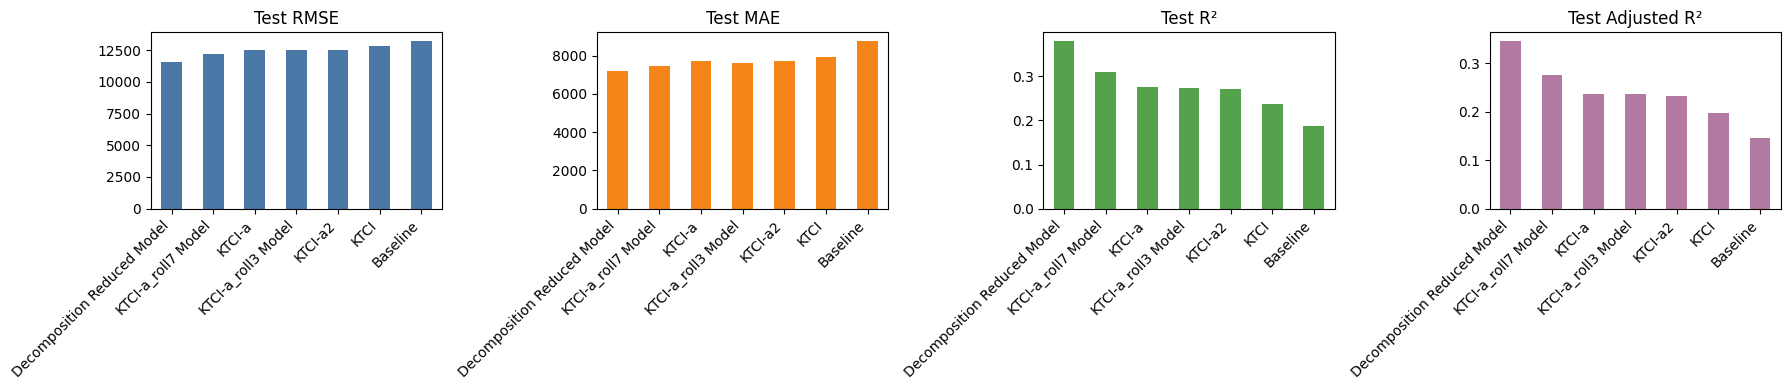

In [40]:
# ============================================================
# 9. 성능 비교
# ============================================================
score_df = pd.DataFrame(scores).sort_values(
    ["RMSE", "MAE", "Adj_R2"],
    ascending=[True, True, False]
)

score_df[["AIC", "BIC", "RMSE", "MAE", "R2", "Adj_R2"]] = (
    score_df[["AIC", "BIC", "RMSE", "MAE", "R2", "Adj_R2"]].round(3)
)

display(score_df[["model", "main_variable", "event_spec", "n_predictors", "AIC", "BIC", "RMSE", "MAE", "R2", "Adj_R2"]])

best_model = score_df.iloc[0]
print(f"Best model by test RMSE: {best_model['model']} ({best_model['main_variable']})")

# 표시용 짧은 이름
score_df["model_short"] = score_df["model"].replace({
    "Decomposition Regression Model": "Decomp.",
    "KTCI-a Model": "KTCI-a",
    "KTCI-a roll3 Model": "KTCI-a r3",
    "KTCI-a2 Model": "KTCI-a2",
    "KTCI Model": "KTCI",
    "Baseline (Temperature)": "Baseline"
})

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

score_df.plot(x="model_short", y="RMSE", kind="bar", ax=axes[0], legend=False, color="#4C78A8")
score_df.plot(x="model_short", y="MAE", kind="bar", ax=axes[1], legend=False, color="#F58518")
score_df.plot(x="model_short", y="R2", kind="bar", ax=axes[2], legend=False, color="#54A24B")
score_df.plot(x="model_short", y="Adj_R2", kind="bar", ax=axes[3], legend=False, color="#B279A2")

axes[0].set_title("Test RMSE")
axes[1].set_title("Test MAE")
axes[2].set_title("Test R²")
axes[3].set_title("Test Adjusted R²")

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xticklabels(ax.get_xticklabels(), ha="right")

plt.tight_layout()
plt.show()

,model,covid_col,n_predictors,RMSE,MAE,R2,Adj_R2,AIC,BIC
0,Baseline (Temperature),covid_v2,18,12825.467222,8623.232679,0.237975,0.198332,119681.767538,119841.886648
1,Baseline (Temperature),covid_v1,18,12906.573248,8638.225339,0.228307,0.188161,119692.463911,119852.583020
2,Baseline (Temperature),covid_v3,18,13237.361414,8783.253254,0.188244,0.146014,119680.663434,119840.782543
3,Decomposition Reduced Model,covid_v2,19,11024.695956,7152.520200,0.436938,0.405929,120003.655093,120170.445831
4,Decomposition Reduced Model,covid_v1,19,11133.038517,7201.346185,0.425817,0.394196,120019.458002,120186.248741
5,Decomposition Reduced Model,covid_v3,19,11567.565396,7215.255516,0.380121,0.345983,120059.619560,120226.410299
6,KTCI-a_roll7 Model,covid_v2,18,11647.969581,7233.822970,0.371474,0.338776,119351.417080,119511.536189
7,KTCI-a_roll7 Model,covid_v1,18,11792.450867,7314.620457,0.355785,0.322271,119382.582235,119542.701344
8,KTCI-a_roll7 Model,covid_v3,18,12200.297964,7462.835594,0.310454,0.274581,119366.443107,119526.562216


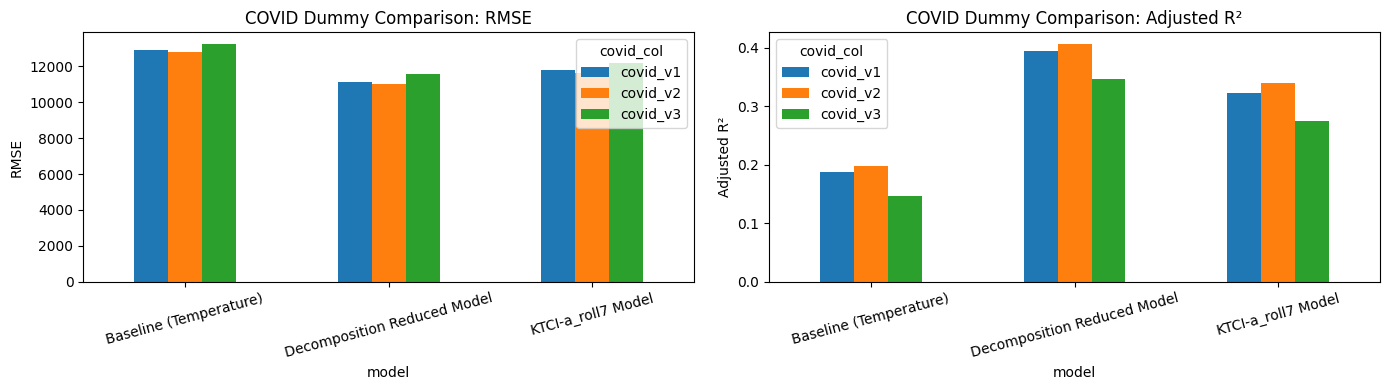

In [41]:
# ============================================================
# 9-1. 코로나 더미(v1/v2/v3) 비교
# ============================================================
covid_compare_rows = []

for compare_model_name in TARGET_COMPARISON_MODELS:
    main_var = MAIN_VARIABLES[compare_model_name]
    for covid_col in COVID_COMPARE_COLS:
        result, pred, score, exog_cols = fit_sarimax_model(
            compare_model_name,
            main_var,
            train_df,
            test_df,
            covid_col=covid_col,
            include_events=DEFAULT_INCLUDE_EVENTS,
        )
        covid_compare_rows.append({
            "model": compare_model_name,
            "covid_col": covid_col,
            **score,
        })

covid_compare_df = pd.DataFrame(covid_compare_rows).sort_values(["model", "RMSE", "Adj_R2"], ascending=[True, True, False]).reset_index(drop=True)
display(
    covid_compare_df[[
        "model",
        "covid_col",
        "n_predictors",
        "RMSE",
        "MAE",
        "R2",
        "Adj_R2",
        "AIC",
        "BIC",
    ]]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
covid_compare_df.pivot(index="model", columns="covid_col", values="RMSE").plot(kind="bar", ax=axes[0])
axes[0].set_title("COVID Dummy Comparison: RMSE")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=15)

covid_compare_df.pivot(index="model", columns="covid_col", values="Adj_R2").plot(kind="bar", ax=axes[1])
axes[1].set_title("COVID Dummy Comparison: Adjusted R²")
axes[1].set_ylabel("Adjusted R²")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


,model,event_spec_label,n_predictors,RMSE,MAE,R2,Adj_R2,AIC,BIC
0,Baseline (Temperature),With Events,18,13237.361414,8783.253254,0.188244,0.146014,119680.663434,119840.782543
1,Baseline (Temperature),No Events,15,13315.242379,8848.337627,0.178664,0.143363,119697.021982,119837.126202
2,Decomposition Reduced Model,No Events,16,10472.058478,6511.602123,0.491973,0.468615,120060.420962,120207.196812
3,Decomposition Reduced Model,With Events,19,11567.565396,7215.255516,0.380121,0.345983,120059.619560,120226.410299
4,KTCI-a_roll7 Model,No Events,15,12020.910918,7345.642365,0.330582,0.301810,119373.037406,119513.141626
5,KTCI-a_roll7 Model,With Events,18,12200.297964,7462.835594,0.310454,0.274581,119366.443107,119526.562216


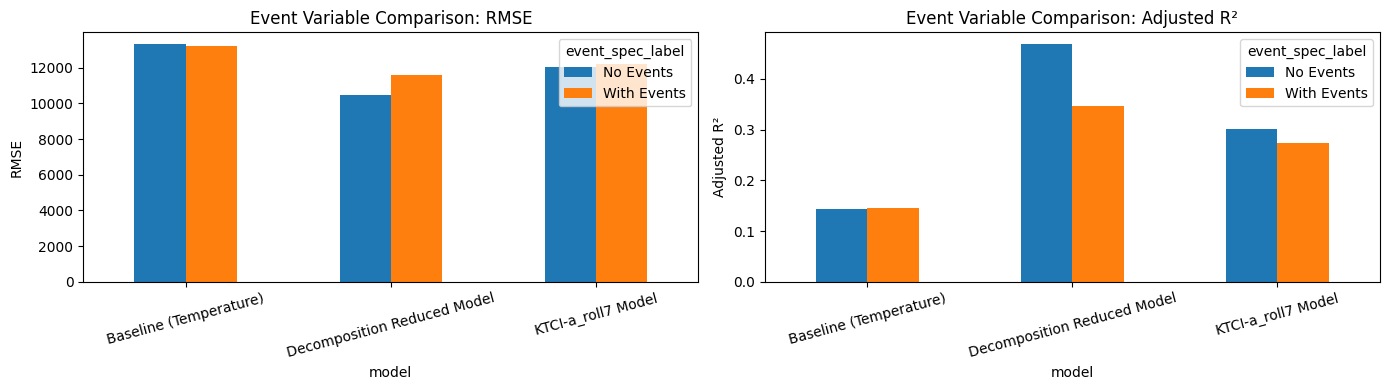

In [42]:
# ============================================================
# 9-2. 이벤트 변수 포함/미포함 비교
# ============================================================
event_compare_rows = []

for compare_model_name in TARGET_COMPARISON_MODELS:
    main_var = MAIN_VARIABLES[compare_model_name]
    for include_events in [False, True]:
        result, pred, score, exog_cols = fit_sarimax_model(
            compare_model_name,
            main_var,
            train_df,
            test_df,
            covid_col=DEFAULT_COVID_COL,
            include_events=include_events,
        )
        event_compare_rows.append({
            "model": compare_model_name,
            "include_events": include_events,
            **score,
        })

event_compare_df = pd.DataFrame(event_compare_rows).sort_values(
    ["model", "RMSE", "Adj_R2"],
    ascending=[True, True, False],
).reset_index(drop=True)
event_compare_df["event_spec_label"] = event_compare_df["include_events"].map({False: "No Events", True: "With Events"})

display(
    event_compare_df[[
        "model",
        "event_spec_label",
        "n_predictors",
        "RMSE",
        "MAE",
        "R2",
        "Adj_R2",
        "AIC",
        "BIC",
    ]]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
event_compare_df.pivot(index="model", columns="event_spec_label", values="RMSE").plot(kind="bar", ax=axes[0])
axes[0].set_title("Event Variable Comparison: RMSE")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=15)

event_compare_df.pivot(index="model", columns="event_spec_label", values="Adj_R2").plot(kind="bar", ax=axes[1])
axes[1].set_title("Event Variable Comparison: Adjusted R²")
axes[1].set_ylabel("Adjusted R²")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


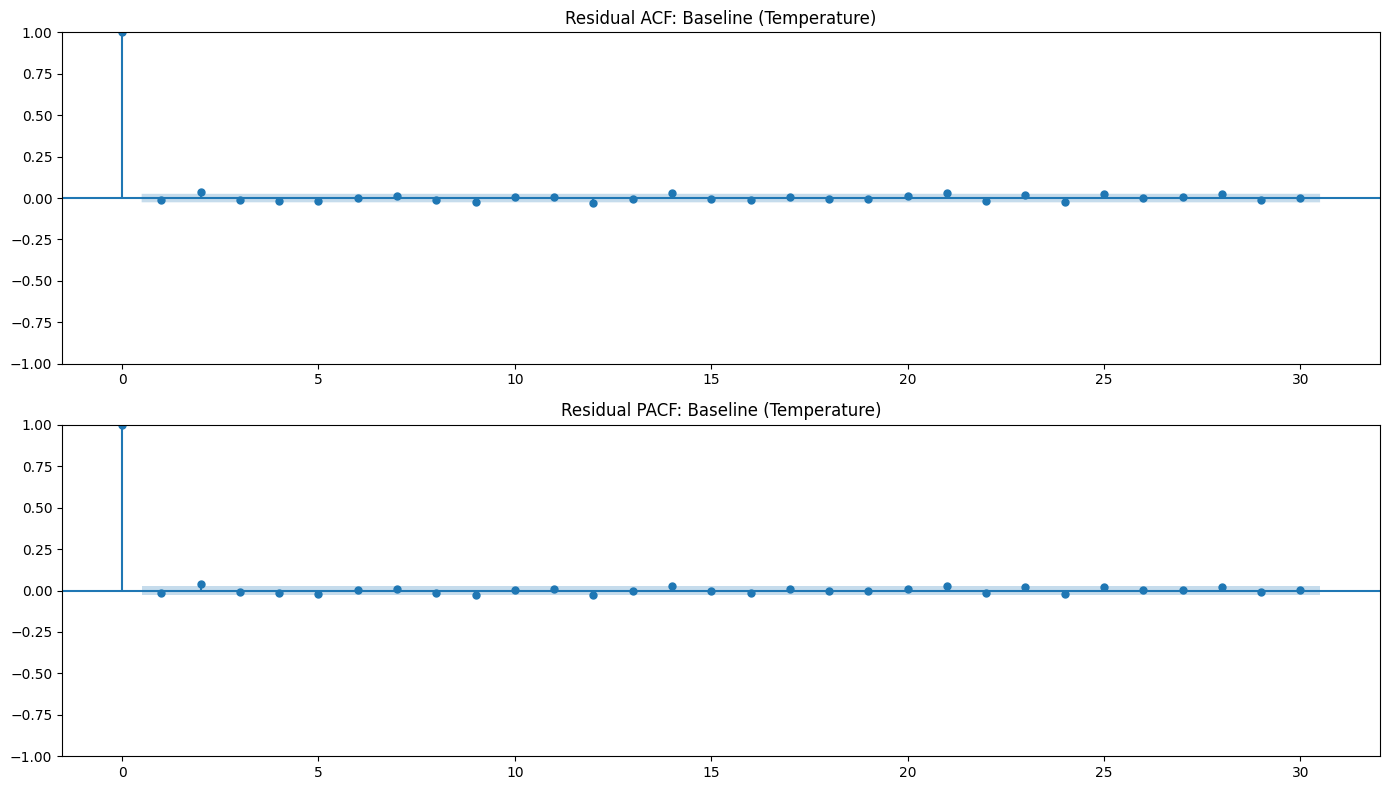

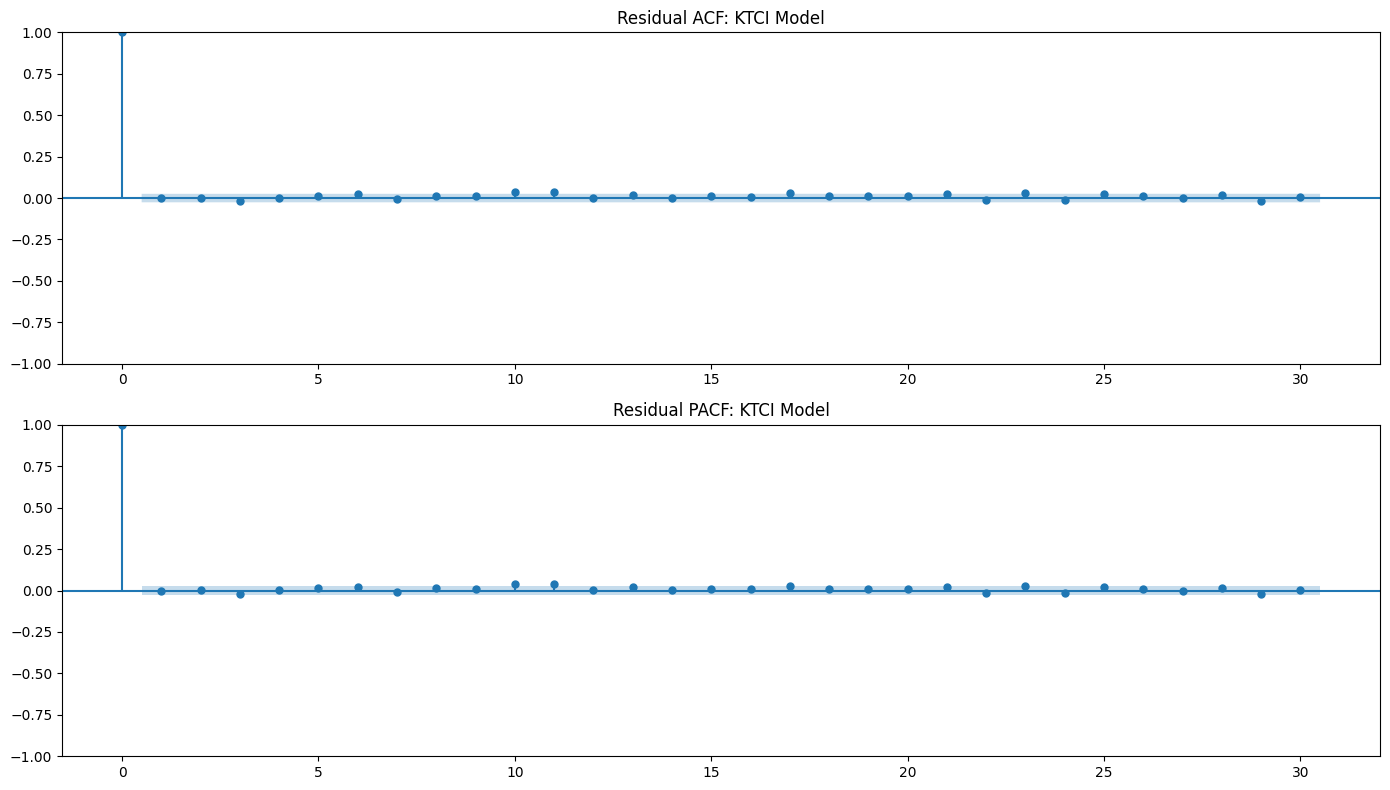

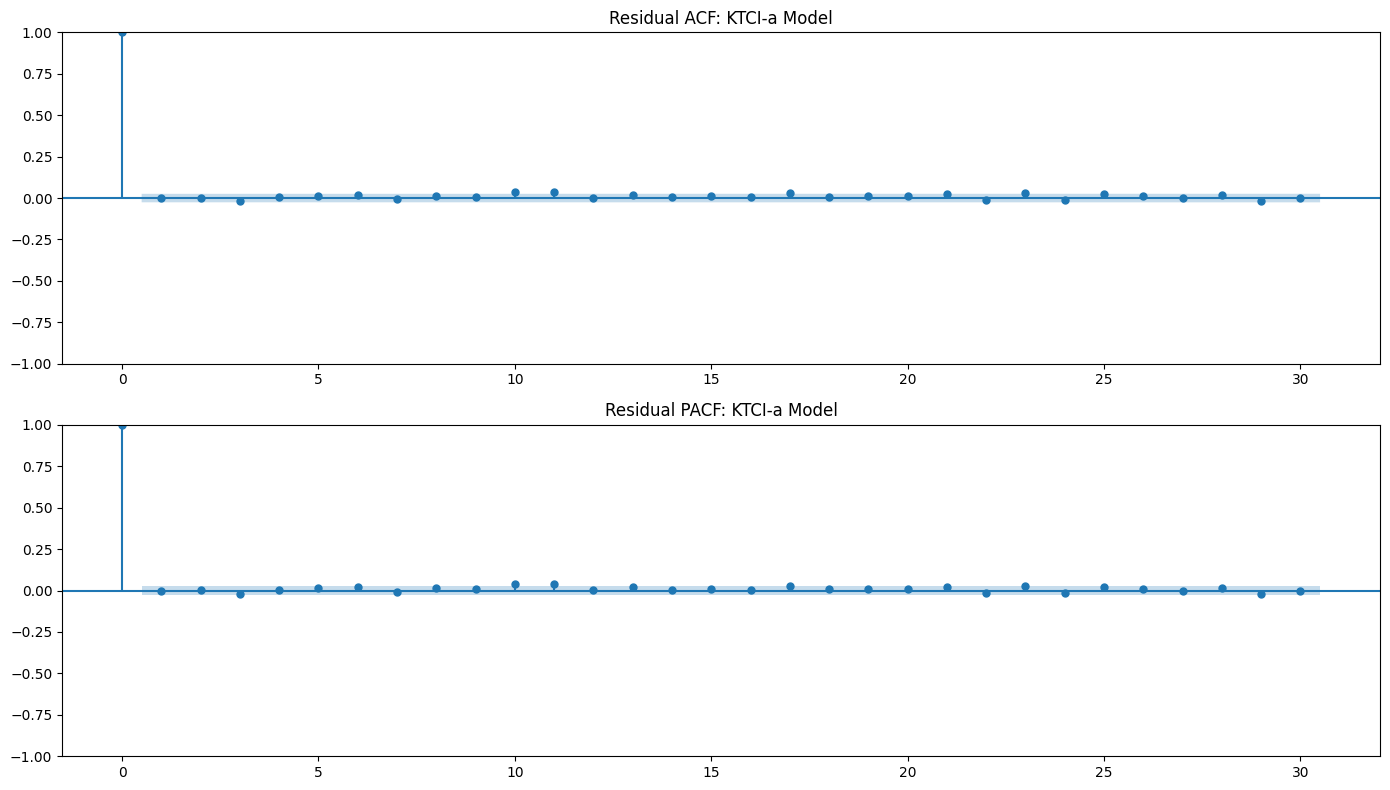

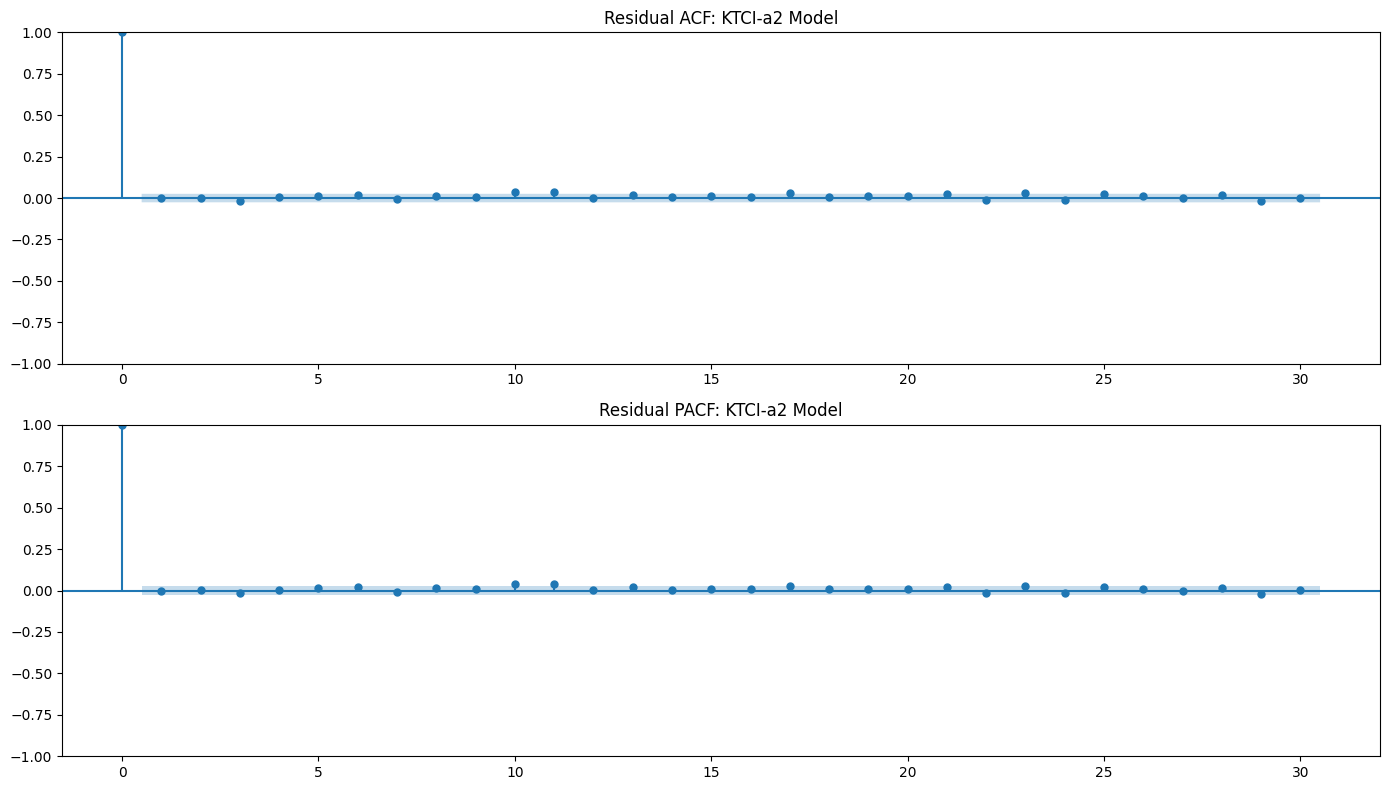

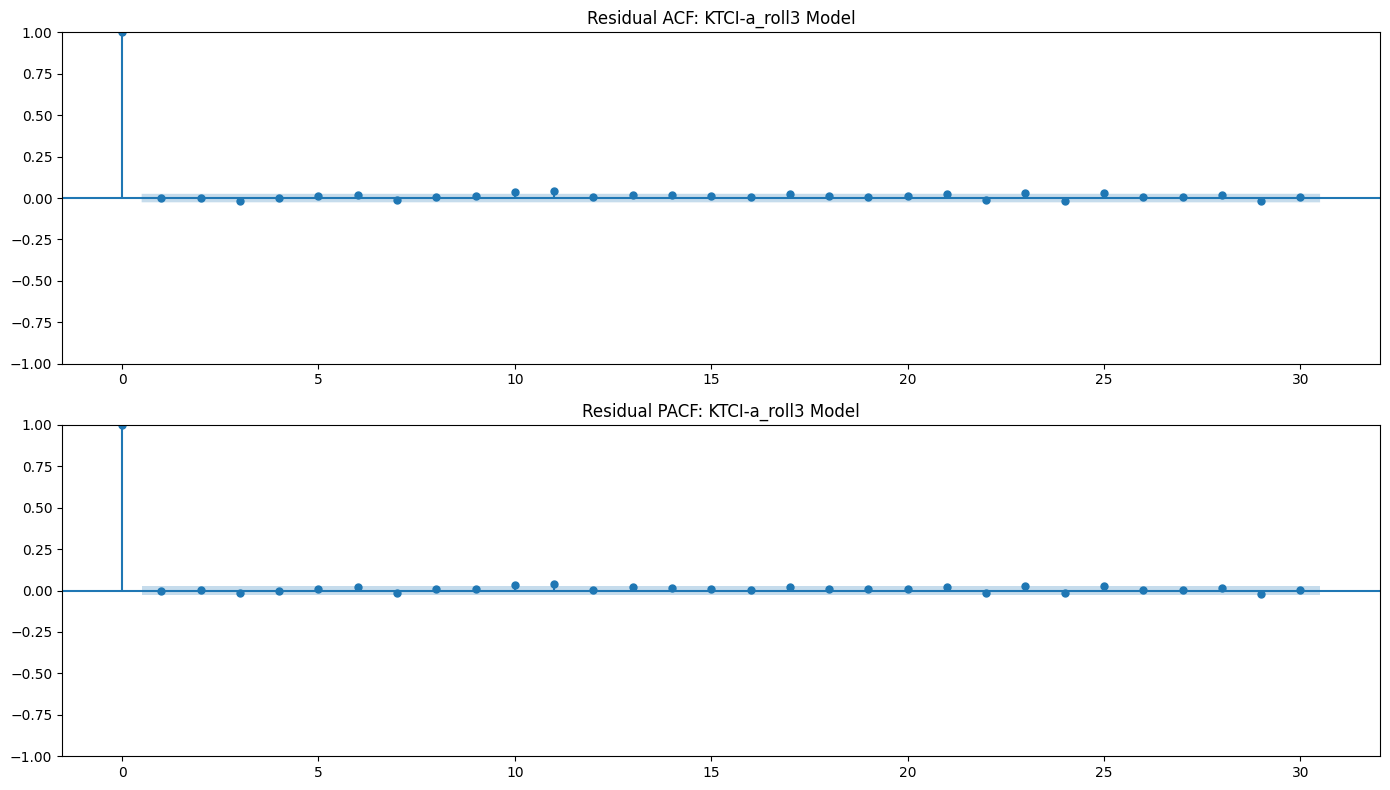

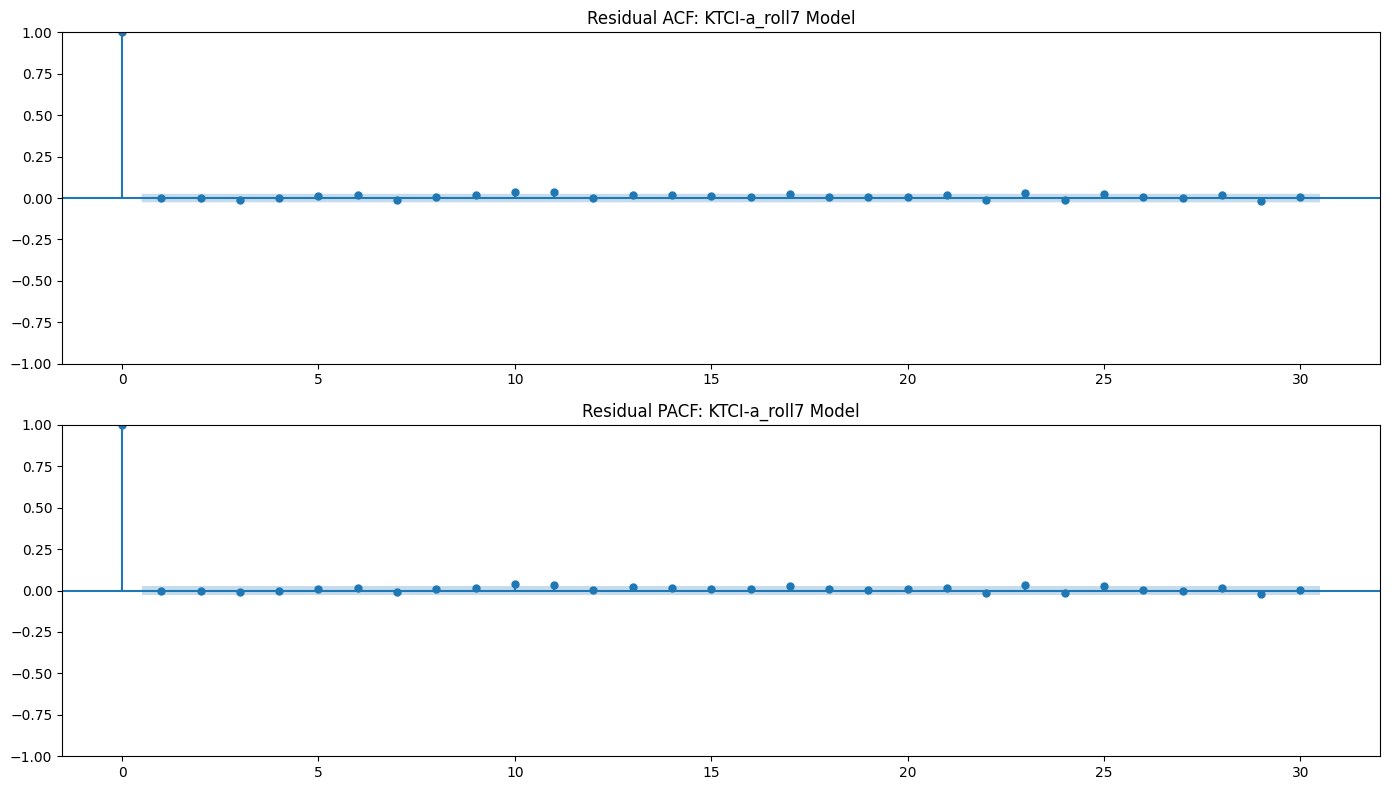

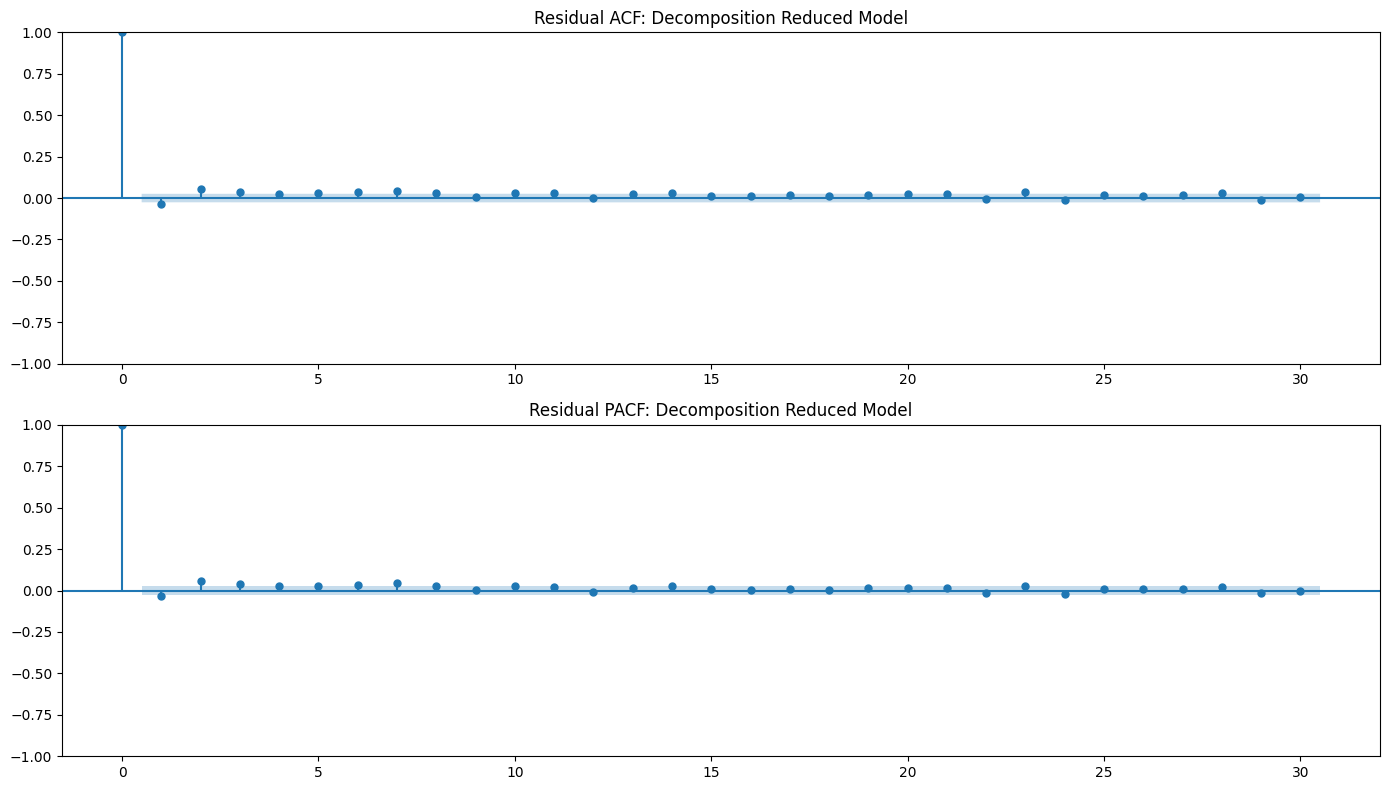

,lag,LB Stat,LB p-value,model
0,7,14.3198,0.0458,Baseline (Temperature)
1,14,28.5239,0.0121,Baseline (Temperature)
2,21,35.9485,0.0222,Baseline (Temperature)
3,7,6.7938,0.4507,KTCI Model
4,14,27.2024,0.0181,KTCI Model
5,21,38.9228,0.0100,KTCI Model
6,7,6.2859,0.5068,KTCI-a Model
7,14,27.2071,0.0181,KTCI-a Model
8,21,39.3844,0.0088,KTCI-a Model
9,7,5.8569,0.5566,KTCI-a2 Model


In [43]:
# ============================================================
# 10. 잔차 진단: ACF/PACF + Ljung-Box
# ============================================================
residual_diagnostics = []
for model_name, result in fitted_results.items():
    resid = result.resid.dropna()

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    plot_acf(resid, ax=axes[0], lags=30, title=f"Residual ACF: {model_name}")
    plot_pacf(resid, ax=axes[1], lags=30, title=f"Residual PACF: {model_name}", method="ywm")
    plt.tight_layout()
    plt.show()

    lb_df = acorr_ljungbox(resid, lags=[7, 14, 21], return_df=True)
    lb_df = lb_df.rename(columns={"lb_stat": "LB Stat", "lb_pvalue": "LB p-value"})
    lb_df["model"] = model_name
    residual_diagnostics.append(lb_df.reset_index().rename(columns={"index": "lag"}))

residual_diag_df = pd.concat(residual_diagnostics, ignore_index=True)
display(residual_diag_df.round(4))



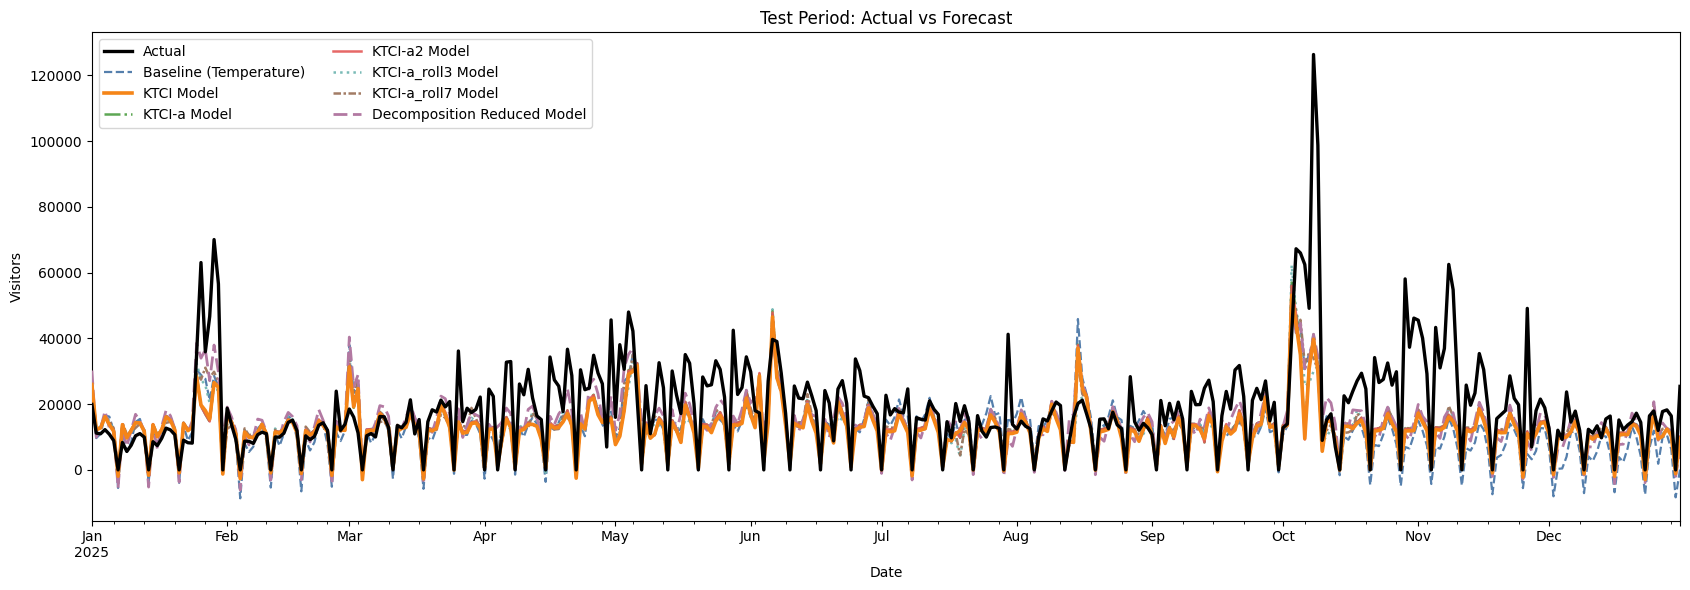

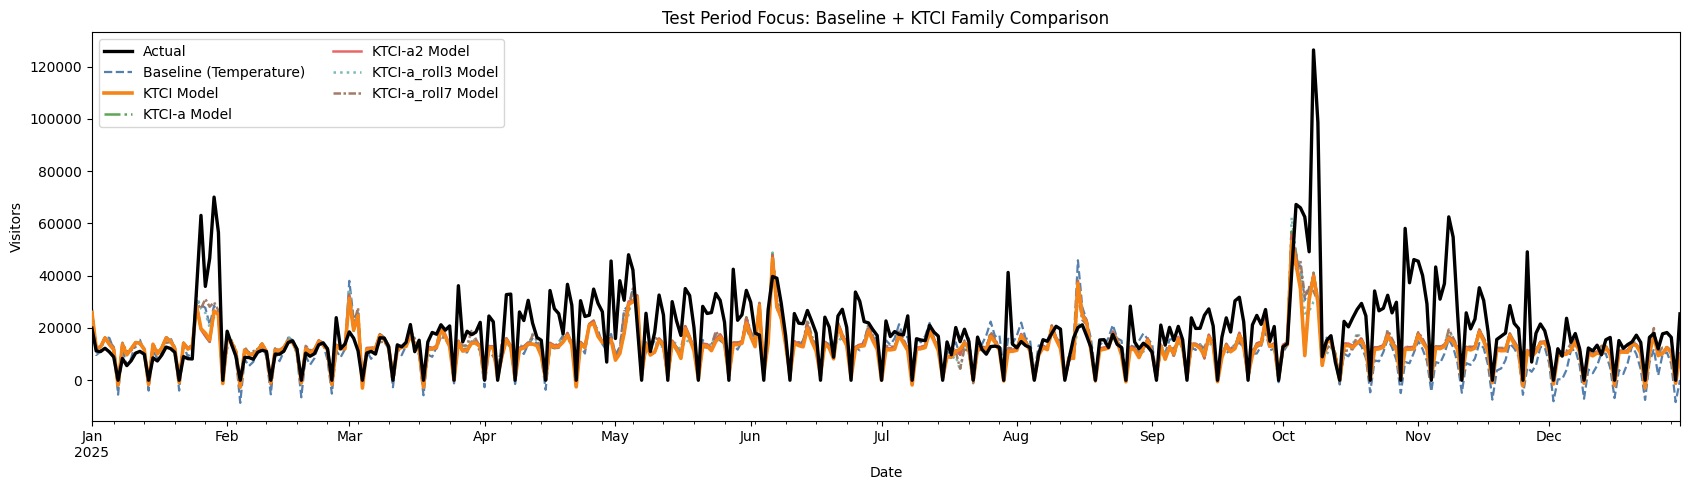

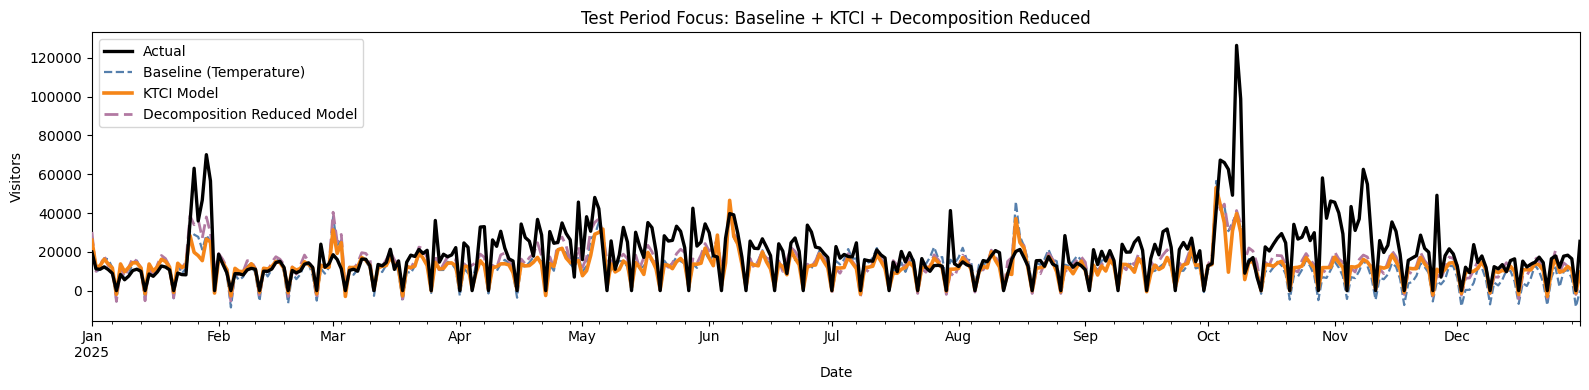

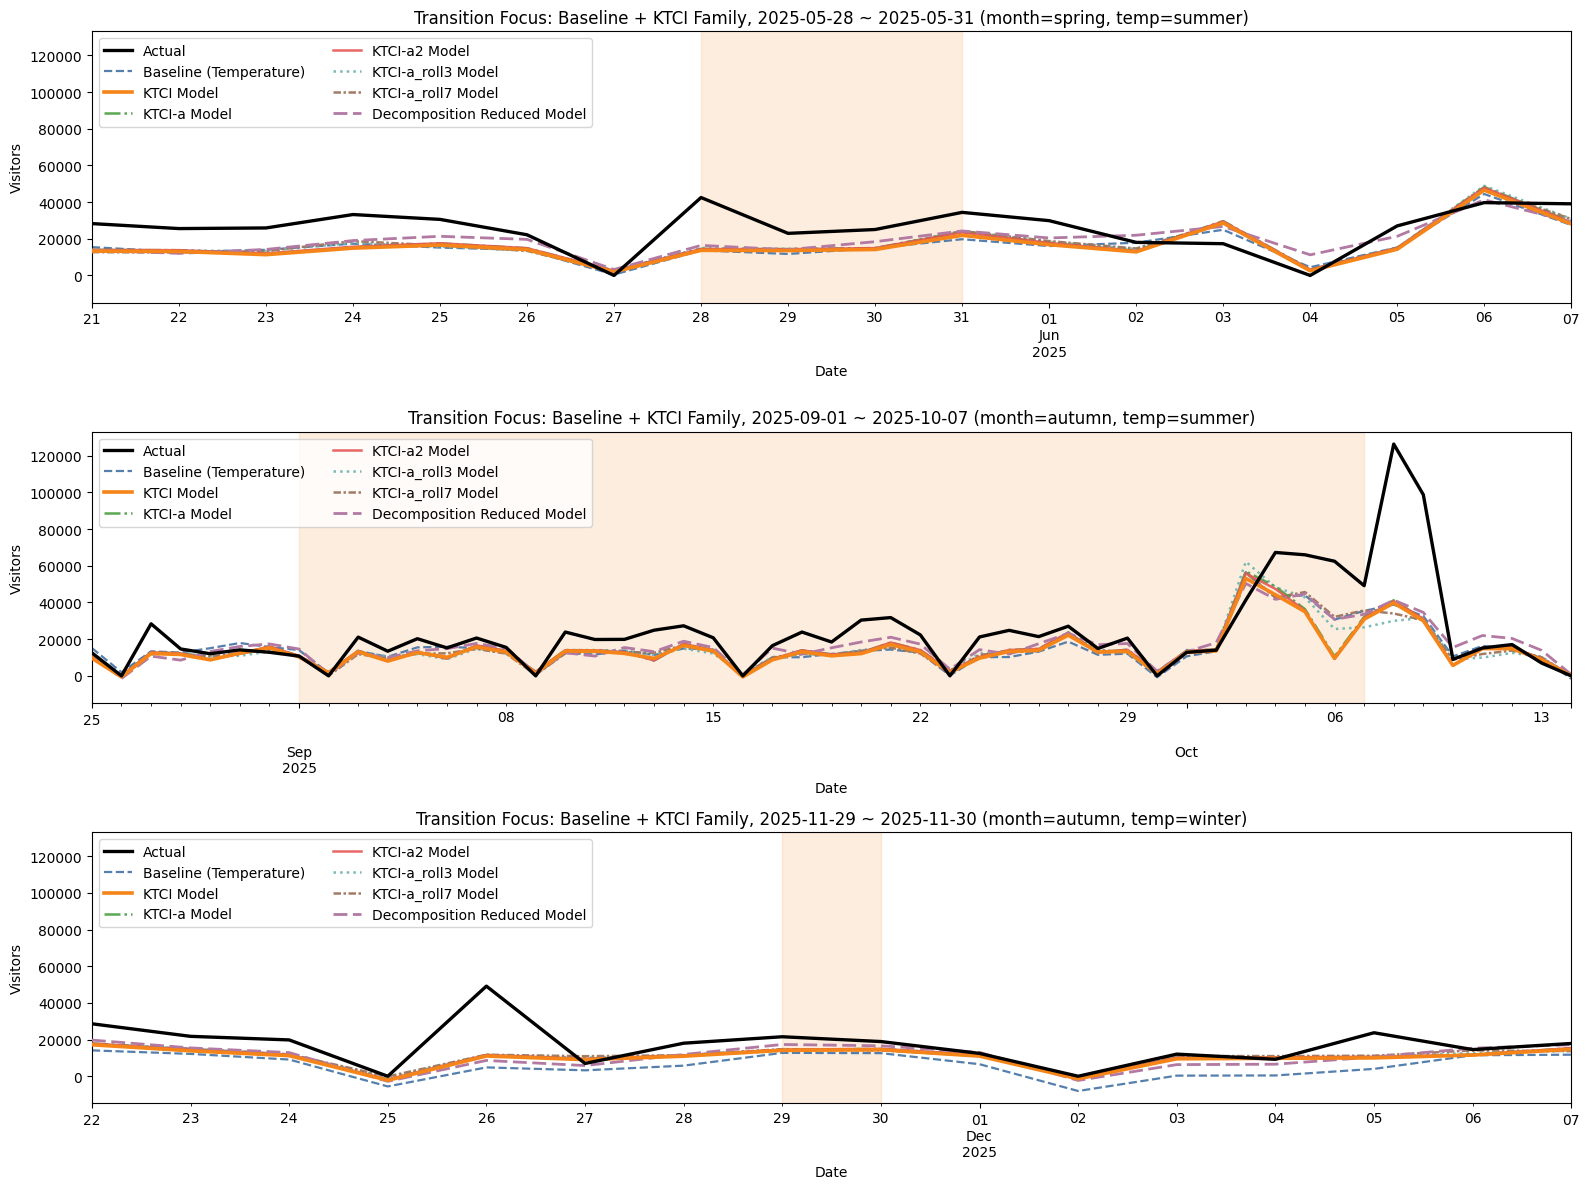

In [44]:
# ============================================================
# 11. Test 구간 실제값 vs 예측값
# ============================================================
plot_df = pd.DataFrame({"actual": test_df[TARGET_COL]})
for model_name, pred in predictions.items():
    plot_df[model_name] = pred

line_styles = {
    "actual": {"color": "black", "linewidth": 2.4, "linestyle": "-", "zorder": 8},
    "Baseline (Temperature)": {"color": "#4C78A8", "linewidth": 1.6, "linestyle": "--", "alpha": 0.95, "zorder": 2},
    "KTCI Model": {"color": "#F58518", "linewidth": 2.6, "linestyle": "-", "alpha": 1.0, "zorder": 7},
    "KTCI-a Model": {"color": "#54A24B", "linewidth": 1.8, "linestyle": "-.", "alpha": 0.95, "zorder": 4},
    "KTCI-a2 Model": {"color": "#E45756", "linewidth": 1.8, "linestyle": "-", "alpha": 0.9, "zorder": 5},
    "KTCI-a_roll3 Model": {"color": "#72B7B2", "linewidth": 1.8, "linestyle": ":", "alpha": 0.95, "zorder": 3},
    "KTCI-a_roll7 Model": {"color": "#9D755D", "linewidth": 1.8, "linestyle": (0, (3, 1, 1, 1)), "alpha": 0.95, "zorder": 3},
    "Decomposition Reduced Model": {"color": "#B279A2", "linewidth": 2.0, "linestyle": (0, (5, 2)), "alpha": 1.0, "zorder": 6},
}

fig, ax = plt.subplots(figsize=(17, 6))
plot_df["actual"].plot(ax=ax, label="Actual", **line_styles["actual"])
for model_name in MAIN_VARIABLES:
    plot_df[model_name].plot(ax=ax, label=model_name, **line_styles[model_name])
ax.set_title("Test Period: Actual vs Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Visitors")
ax.legend(loc="upper left", frameon=True, ncol=2)
plt.tight_layout()
plt.show()

# KTCI 계열 세부 비교 + Baseline
fig, ax = plt.subplots(figsize=(17, 5))
plot_df["actual"].plot(ax=ax, label="Actual", **line_styles["actual"])
plot_df["Baseline (Temperature)"].plot(ax=ax, label="Baseline (Temperature)", **line_styles["Baseline (Temperature)"])
for model_name in ["KTCI Model", "KTCI-a Model", "KTCI-a2 Model", "KTCI-a_roll3 Model", "KTCI-a_roll7 Model"]:
    plot_df[model_name].plot(ax=ax, label=model_name, **line_styles[model_name])
ax.set_title("Test Period Focus: Baseline + KTCI Family Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Visitors")
ax.legend(loc="upper left", frameon=True, ncol=2)
plt.tight_layout()
plt.show()

# 저공선성 분해모델 vs KTCI 비교 확대 + Baseline
fig, ax = plt.subplots(figsize=(16, 4))
plot_df["actual"].plot(ax=ax, label="Actual", **line_styles["actual"])
plot_df["Baseline (Temperature)"].plot(ax=ax, label="Baseline (Temperature)", **line_styles["Baseline (Temperature)"])
plot_df["KTCI Model"].plot(ax=ax, label="KTCI Model", **line_styles["KTCI Model"])
plot_df["Decomposition Reduced Model"].plot(ax=ax, label="Decomposition Reduced Model", **line_styles["Decomposition Reduced Model"])
ax.set_title("Test Period Focus: Baseline + KTCI + Decomposition Reduced")
ax.set_xlabel("Date")
ax.set_ylabel("Visitors")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

# 환절기(월 기준 계절 != 기온 기준 계절) 구간만 확대 시각화
season_compare = df.loc[test_df.index, ["season_month", "season_temp"]].copy()
season_compare["is_transition"] = season_compare["season_month"] != season_compare["season_temp"]

if season_compare["is_transition"].any():
    transition_dates = season_compare.index[season_compare["is_transition"]]
    transition_blocks = []
    block_start = transition_dates[0]
    prev_date = transition_dates[0]

    for current_date in transition_dates[1:]:
        if (current_date - prev_date).days > 1:
            transition_blocks.append((block_start, prev_date))
            block_start = current_date
        prev_date = current_date
    transition_blocks.append((block_start, prev_date))

    context_days = 7
    fig, axes = plt.subplots(
        len(transition_blocks),
        1,
        figsize=(16, 4 * len(transition_blocks)),
        sharey=True,
    )
    if len(transition_blocks) == 1:
        axes = [axes]

    for ax, (start_date, end_date) in zip(axes, transition_blocks):
        window_start = start_date - pd.Timedelta(days=context_days)
        window_end = end_date + pd.Timedelta(days=context_days)
        window_df = plot_df.loc[(plot_df.index >= window_start) & (plot_df.index <= window_end)]

        window_df["actual"].plot(ax=ax, label="Actual", **line_styles["actual"])
        window_df["Baseline (Temperature)"].plot(ax=ax, label="Baseline (Temperature)", **line_styles["Baseline (Temperature)"])
        for model_name in ["KTCI Model", "KTCI-a Model", "KTCI-a2 Model", "KTCI-a_roll3 Model", "KTCI-a_roll7 Model", "Decomposition Reduced Model"]:
            window_df[model_name].plot(ax=ax, label=model_name, **line_styles[model_name])

        month_season = season_compare.loc[start_date, "season_month"]
        temp_season = season_compare.loc[start_date, "season_temp"]
        ax.axvspan(start_date, end_date, color="#F58518", alpha=0.14)
        ax.set_title(
            f"Transition Focus: Baseline + KTCI Family, {start_date.date()} ~ {end_date.date()} "
            f"(month={month_season}, temp={temp_season})"
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("Visitors")
        ax.legend(loc="upper left", frameon=True, ncol=2)

    plt.tight_layout()
    plt.show()
else:
    print("Test 구간에는 month 기준 계절과 temperature 기준 계절이 다른 환절기 구간이 없습니다.")


In [45]:
# ============================================================
# 12. 주요 계수 비교
# ============================================================
coef_rows = []
for model_name, result in fitted_results.items():
    for term, coef, p_value in zip(result.params.index, result.params.values, result.pvalues.values):
        coef_rows.append({
            "model": model_name,
            "term": term,
            "coef": coef,
            "p_value": p_value,
        })

coef_df = pd.DataFrame(coef_rows)
important_terms = [
    *SCALAR_MAIN_VARS,
    *REDUCED_DECOMP_COLS,
    "offdays_left",
    "long_break_3p",
    "pre_holiday",
    "rain_c_x_weekend",
    "rain_c_x_offdays_left",
    *[f"{var}_c_x_weekend" for var in SCALAR_MAIN_VARS],
    *[f"{var}_c_x_offdays_left" for var in SCALAR_MAIN_VARS],
    *COVID_COMPARE_COLS,
    *BASE_CONTROL_COLS,
    *EVENT_CONTROL_COLS,
]
display(
    coef_df[coef_df["term"].isin(important_terms)]
    .sort_values(["model", "p_value"])
    .reset_index(drop=True)
)


,model,term,coef,p_value
0,Baseline (Temperature),d_holiday,11631.858746,2.632332e-242
1,Baseline (Temperature),offdays_left,2581.294554,1.690521e-60
2,Baseline (Temperature),tavg_c_x_offdays_left,162.017446,1.392112e-50
3,Baseline (Temperature),long_break_3p,7141.753852,3.115576e-49
4,Baseline (Temperature),closed,-8814.755830,2.792053e-41
...,...,...,...,...
122,KTCI-a_roll7 Model,event_day,2153.079171,2.661309e-02
123,KTCI-a_roll7 Model,is_weekend,934.954148,6.875332e-02
124,KTCI-a_roll7 Model,pm10,2.056063,6.859050e-01
125,KTCI-a_roll7 Model,pre_holiday,183.230140,6.873240e-01


## 해석 팁

- 최종 비교는 `test RMSE`, `test MAE`, `test R²`를 우선 보세요.
- `AIC`, `BIC`는 학습 구간 적합도 지표라 참고용입니다.
- `Baseline (Temperature)`보다 `KTCI Model` 또는 `KTCI-a Model`의 test 성능이 좋아야, 온도를 KTCI 계열 지표로 대체할 실익이 있다고 볼 수 있습니다.
- `KTCI`와 `KTCI-a`가 비슷하면, 해석이 더 쉬운 쪽을 선택하면 됩니다. 차이가 크면 `계절 정의`가 실제 방문객 패턴을 더 잘 설명한 셈입니다.
